# Build 1 — Data Audit and Synthetic-Data EDA

Kaggle Playground Series S6E8 — Predicting Smartphone Addiction

**Purpose of this notebook:** understand the training and test data deeply
enough that Build 2 can start with a trustworthy validation strategy and a
justified baseline. This is a data audit, not a modeling notebook.

**Out of scope for this notebook:** model training, cross-validated ROC AUC,
submission files, final feature engineering.

Each section states a question, the method used to answer it, the
observation, and the modeling/validation implication.

## 1. Setup and data loading

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from src.config import (
    TRAIN_PATH,
    TEST_PATH,
    SAMPLE_SUBMISSION_PATH,
    OUTPUTS_DIR,
    FIGURES_DIR,
    TARGET_COLUMN,
    RANDOM_SEED,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

OUTPUTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True, parents=True)

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("train shape:", train.shape)
print("test shape:", test.shape)
print("sample_submission shape:", sample_submission.shape)

train shape: (691369, 14)
test shape: (296302, 13)
sample_submission shape: (296302, 2)


In [2]:
ID_COL = "id"
PREDICTOR_COLS = [c for c in train.columns if c not in (ID_COL, TARGET_COLUMN)]
NUMERIC_COLS = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
]
CATEGORICAL_COLS = ["gender", "stress_level", "academic_work_impact"]

assert set(NUMERIC_COLS) | set(CATEGORICAL_COLS) == set(PREDICTOR_COLS)
print("predictor columns:", PREDICTOR_COLS)

predictor columns: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']


**Observation:** train has 691,369 rows and 14 columns (13 predictors +
`id` + target); test has 296,302 rows and 13 columns (same predictors +
`id`, no target). Predictor columns are split into 9 numeric and 3
categorical.

## 2. Schema audit

**Question:** What exactly is in each column — dtype, non-null counts,
cardinality, and range — and are train/test predictor columns identical?

**Method:** build one summary table per column with dtype, non-null counts
in both splits, unique counts, and numeric ranges.

In [3]:
schema_rows = []
for col in train.columns:
    in_test = col in test.columns
    is_numeric = pd.api.types.is_numeric_dtype(train[col])
    schema_rows.append({
        "column": col,
        "dtype": str(train[col].dtype),
        "train_non_null": train[col].notna().sum(),
        "test_non_null": test[col].notna().sum() if in_test else None,
        "train_nunique": train[col].nunique(dropna=True),
        "test_nunique": test[col].nunique(dropna=True) if in_test else None,
        "train_min": train[col].min() if is_numeric else None,
        "train_max": train[col].max() if is_numeric else None,
        "test_min": test[col].min() if (in_test and is_numeric) else None,
        "test_max": test[col].max() if (in_test and is_numeric) else None,
    })
schema = pd.DataFrame(schema_rows)
schema.to_csv(OUTPUTS_DIR / "schema_summary.csv", index=False)
schema

,column,dtype,train_non_null,test_non_null,train_nunique,test_nunique,train_min,train_max,test_min,test_max
0,id,int64,691369,296302.0,691369,296302.0,0.00,691368.00,691369.00,987670.00
1,age,float64,662440,279164.0,18,18.0,18.00,35.00,18.00,35.00
2,daily_screen_time_hours,float64,595515,263514.0,1389,1349.0,0.50,15.00,0.50,15.00
3,social_media_hours,float64,557374,248905.0,721,703.0,0.00,8.00,0.00,7.85
4,gaming_hours,float64,564548,236882.0,401,401.0,0.00,4.00,0.00,4.00
5,work_study_hours,float64,639851,268525.0,600,601.0,0.00,6.00,0.00,6.00
6,sleep_hours,float64,646889,273847.0,451,451.0,4.50,9.00,4.50,9.00
7,notifications_per_day,float64,623785,262081.0,231,231.0,20.00,250.00,20.00,250.00
8,app_opens_per_day,float64,610659,270597.0,166,166.0,15.00,180.00,15.00,180.00
9,weekend_screen_time,float64,579306,245605.0,1437,1404.0,0.51,17.56,0.51,17.56


In [4]:
predictors_match = set(train.columns) - {TARGET_COLUMN} == set(test.columns)
print("train predictor columns == test columns:", predictors_match)
print()
print("dtypes:")
print(train.dtypes)

train predictor columns == test columns: True

dtypes:
id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                         str
stress_level                   str
academic_work_impact           str
addicted_label               int64
dtype: object


**Observation:**
- Train and test have identical predictor columns; only `addicted_label`
  is unique to train.
- `age` is stored as float but only takes 18 integer values (18-35) in both
  splits — an integer-valued age represented as float, most likely because
  of missing values in the column.
- `notifications_per_day` and `app_opens_per_day` are float-typed but every
  observed value is a whole number (verified in Section 6) — count features
  stored as float purely because of missingness, not because they are
  continuous.
- `daily_screen_time_hours`, `social_media_hours`, `gaming_hours`,
  `work_study_hours`, `sleep_hours`, `weekend_screen_time` are genuinely
  continuous, rounded to 2 decimal places.
- `gender` (3 categories), `stress_level` (3 categories),
  `academic_work_impact` (2 categories) are string categoricals.
- No column present in test is absent from train or vice versa; no dtype
  inconsistency between train and test.
- `id` is a unique integer per row in both splits (audited in depth in
  Section 13).

**Implication:** no schema-parity issues that would break a shared
preprocessing pipeline between train and test. Age and the two count
features should be treated as discrete/ordinal despite their float dtype —
this matters when deciding whether to scale them or bin them in Build 2.

## 3. Target audit

**Question:** How imbalanced is `addicted_label`?

**Method:** class counts and proportions on train (target does not exist in
test).

In [5]:
target_counts = train[TARGET_COLUMN].value_counts().sort_index()
target_props = train[TARGET_COLUMN].value_counts(normalize=True).sort_index()
target_summary = pd.DataFrame({"count": target_counts, "proportion": target_props})
target_summary

,count,proportion
addicted_label,,
0,200895,0.290576
1,490474,0.709424


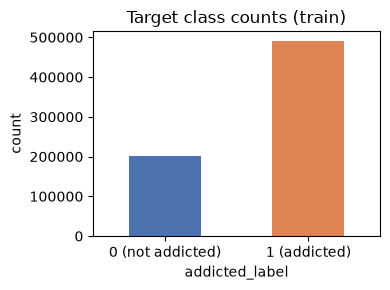

In [6]:
fig, ax = plt.subplots(figsize=(4, 3))
target_counts.sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xlabel("addicted_label")
ax.set_ylabel("count")
ax.set_title("Target class counts (train)")
ax.set_xticklabels(["0 (not addicted)", "1 (addicted)"], rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "target_balance.png", dpi=120)
plt.show()

**Observation:** the positive class (`addicted_label == 1`) makes up
70.9% of train (490,474 rows); the negative class makes up 29.1%
(200,895 rows). This is a moderate imbalance (roughly 2.4:1), not severe.

**Implication:** ROC AUC (the competition metric) is threshold-independent
and reasonably robust to this level of imbalance, so class weighting or
resampling should not be assumed necessary as a starting point — this will
only be revisited if a baseline model shows the classifier collapsing to
the majority class. Stratified splitting is still worthwhile to keep the
~70.9%/29.1% ratio stable across folds.

## 4. Missing-value audit

### 4.1 Train vs test missingness

**Question:** How much missingness does each predictor have in train and
test, and do the two splits differ?

**Method:** missing count and percentage per column in both splits, sorted
by the size of the train/test gap.

In [7]:
miss_rows = []
for col in PREDICTOR_COLS:
    tr_miss = train[col].isna().sum()
    te_miss = test[col].isna().sum()
    tr_pct = tr_miss / len(train) * 100
    te_pct = te_miss / len(test) * 100
    miss_rows.append({
        "column": col,
        "train_missing": tr_miss,
        "train_missing_pct": round(tr_pct, 3),
        "test_missing": te_miss,
        "test_missing_pct": round(te_pct, 3),
        "diff_pp": round(tr_pct - te_pct, 3),
    })
missingness = pd.DataFrame(miss_rows).sort_values("diff_pp", key=abs, ascending=False)
missingness.to_csv(OUTPUTS_DIR / "missingness_summary.csv", index=False)
missingness

,column,train_missing,train_missing_pct,test_missing,test_missing_pct,diff_pp
2,social_media_hours,133995,19.381,47397,15.996,3.385
7,app_opens_per_day,80710,11.674,25705,8.675,2.999
1,daily_screen_time_hours,95854,13.864,32788,11.066,2.799
11,academic_work_impact,44224,6.397,25721,8.681,-2.284
4,work_study_hours,51518,7.452,27777,9.375,-1.923
6,notifications_per_day,67584,9.775,34221,11.549,-1.774
3,gaming_hours,126821,18.343,59420,20.054,-1.710
0,age,28929,4.184,17138,5.784,-1.600
10,stress_level,55148,7.977,19626,6.624,1.353
5,sleep_hours,44480,6.434,22455,7.578,-1.145


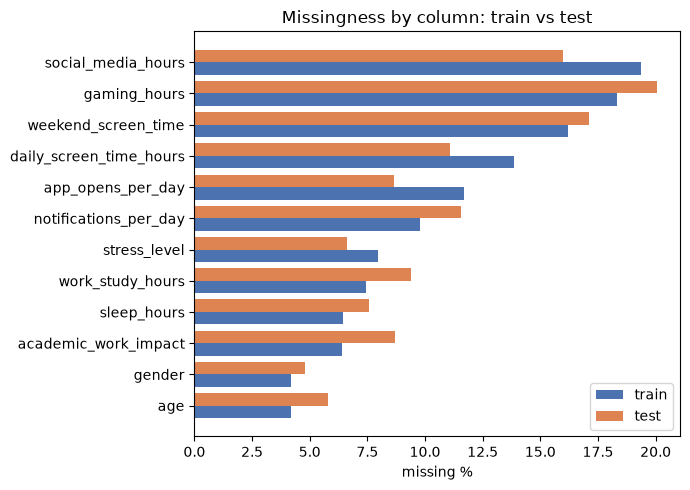

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_df = missingness.sort_values("train_missing_pct")
y = np.arange(len(plot_df))
ax.barh(y - 0.2, plot_df["train_missing_pct"], height=0.4, label="train", color="#4C72B0")
ax.barh(y + 0.2, plot_df["test_missing_pct"], height=0.4, label="test", color="#DD8452")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["column"])
ax.set_xlabel("missing %")
ax.set_title("Missingness by column: train vs test")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "missingness_train_vs_test.png", dpi=120)
plt.show()

**Observation:** every predictor has missingness, ranging from ~4.2%
(`gender`) to ~19.4% (`social_media_hours`) in train. Train/test gaps are
small in absolute terms (largest is `social_media_hours` at 3.4 percentage
points; most columns differ by under 2 points). Missingness rates are
broadly similar between train and test — the differences look like sampling
noise rather than a systematically different missingness mechanism, but
this is not tested formally here (see Section 9 for train/test shift more
generally).

**Implication:** every predictor will need an explicit missing-value
strategy in Build 2 — there is no column that can be handled by simple
listwise deletion without losing a large share of rows (row-level deletion
would discard the ~61% of train rows that have at least one missing
value — see 4.2 below).

### 4.2 Missingness vs target

**Question:** Does missingness in a column, or the total number of missing
predictors in a row, carry information about the target?

**Method:** for each predictor, compare the target rate among rows where it
is missing vs observed, with a two-proportion z-test for the difference.
Separately, look at target rate as a function of `row_missing_count` (a
temporary diagnostic column, not a permanent feature).

In [9]:
mvt_rows = []
for col in PREDICTOR_COLS:
    is_missing = train[col].isna()
    if is_missing.sum() == 0:
        continue
    rate_missing = train.loc[is_missing, TARGET_COLUMN].mean()
    rate_observed = train.loc[~is_missing, TARGET_COLUMN].mean()
    n_missing = is_missing.sum()
    n_observed = (~is_missing).sum()
    count = np.array([
        train.loc[is_missing, TARGET_COLUMN].sum(),
        train.loc[~is_missing, TARGET_COLUMN].sum(),
    ])
    nobs = np.array([n_missing, n_observed])
    p_pool = count.sum() / nobs.sum()
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / nobs[0] + 1 / nobs[1]))
    z = (rate_missing - rate_observed) / se if se > 0 else np.nan
    pval = 2 * (1 - stats.norm.cdf(abs(z))) if not np.isnan(z) else np.nan
    mvt_rows.append({
        "column": col,
        "rate_when_missing": round(rate_missing, 4),
        "rate_when_observed": round(rate_observed, 4),
        "diff_pp": round((rate_missing - rate_observed) * 100, 3),
        "n_missing": n_missing,
        "z": round(z, 2) if not np.isnan(z) else None,
        "p_value": round(pval, 5) if not np.isnan(pval) else None,
    })
missing_vs_target = pd.DataFrame(mvt_rows).sort_values("diff_pp", key=abs, ascending=False)
missing_vs_target.to_csv(OUTPUTS_DIR / "missingness_vs_target.csv", index=False)
missing_vs_target

,column,rate_when_missing,rate_when_observed,diff_pp,n_missing,z,p_value
5,sleep_hours,0.7134,0.7092,0.422,44480,1.90,0.05769
0,age,0.7134,0.7093,0.415,28929,1.52,0.12796
7,app_opens_per_day,0.7128,0.7090,0.381,80710,2.24,0.02519
1,daily_screen_time_hours,0.7113,0.7091,0.218,95854,1.38,0.16805
8,weekend_screen_time,0.7107,0.7092,0.147,112063,0.99,0.32202
3,gaming_hours,0.7105,0.7092,0.132,126821,0.94,0.34808
4,work_study_hours,0.7106,0.7093,0.132,51518,0.63,0.52593
6,notifications_per_day,0.7102,0.7093,0.091,67584,0.49,0.62206
9,gender,0.7088,0.7095,-0.066,29034,-0.24,0.80774
10,stress_level,0.7090,0.7095,-0.046,55148,-0.23,0.81954


In [10]:
row_missing_count = train[PREDICTOR_COLS].isna().sum(axis=1)
target_by_row_missing = (
    pd.DataFrame({"row_missing_count": row_missing_count, TARGET_COLUMN: train[TARGET_COLUMN]})
    .groupby("row_missing_count")[TARGET_COLUMN]
    .agg(["mean", "count"])
)
target_by_row_missing

,mean,count
row_missing_count,,
0,0.708123,269185
1,0.708970,180459
2,0.711178,120697
3,0.711784,67328
4,0.709494,32557
5,0.712458,13678
6,0.719217,5157
7,0.696301,1676
8,0.702306,477


**Observation:**
- Per-column missingness vs target: the largest absolute effect is
  `sleep_hours` at +0.42 percentage points (target rate 71.3% when missing
  vs 70.9% when observed, p ≈ 0.06). `app_opens_per_day` reaches
  significance at p ≈ 0.025 but the effect is only +0.38 points. Every
  other column is smaller and/or not significant. With ~600-650k
  observations per column, even trivial effects can reach conventional
  significance thresholds — none of these differences are large enough to
  be practically useful signal.
- `row_missing_count` vs target rate: flat at ~70.8-71.2% for 0-6 missing
  predictors (which covers the overwhelming majority of rows), with more
  erratic rates only in the sparse tail (7+ missing, where row counts drop
  below ~1,700 and the estimate is noisy).

**Implication:** missingness does not appear informative about the target
in this dataset — neither per-column nor via a total-missing-count
diagnostic. Missing indicators are not ruled out as a Build 2 experiment
(they are cheap to test), but Build 1 evidence does not support expecting
them to help.

## 5. Duplicate and repeated-pattern audit

This matters directly for validation trustworthiness: if predictor vectors
repeat and always carry the same target, random row-level K-fold CV could
let near-identical rows leak across the train/validation split.

### 5.1 Exact full-row duplicates

In [11]:
print("train full-row duplicates (incl. id, expected 0):", train.duplicated().sum())
print("test full-row duplicates (incl. id, expected 0):", test.duplicated().sum())

train full-row duplicates (incl. id, expected 0): 0


test full-row duplicates (incl. id, expected 0): 0


### 5.2 Predictor-only duplicates (excluding `id` and `addicted_label`)

**Method:** hash each row's predictor values (vectorized,
`pandas.util.hash_pandas_object`) rather than comparing rows directly, to
keep this memory-safe at ~700k/~300k rows.

In [12]:
def hash_rows(df, cols):
    return pd.util.hash_pandas_object(df[cols], index=False)

train_hash = hash_rows(train, PREDICTOR_COLS)
test_hash = hash_rows(test, PREDICTOR_COLS)

train_dup_mask = train_hash.duplicated(keep=False)
test_dup_mask = test_hash.duplicated(keep=False)

print("train rows sharing a predictor vector with >=1 other row:", train_dup_mask.sum())
print("test rows sharing a predictor vector with >=1 other row:", test_dup_mask.sum())

train rows sharing a predictor vector with >=1 other row: 0
test rows sharing a predictor vector with >=1 other row: 0


### 5.3 Target consistency among duplicate predictor groups

No predictor-vector duplicates were found within train (Section 5.2 above
shows 0 duplicated rows), so there are no duplicate groups to check for
target consistency. This is recorded explicitly because it is a load-bearing
fact for the Build 2 validation recommendation.

In [13]:
if train_dup_mask.sum() > 0:
    grouped = (
        pd.DataFrame({"h": train_hash, TARGET_COLUMN: train[TARGET_COLUMN]})[train_dup_mask]
        .groupby("h")[TARGET_COLUMN]
        .agg(["nunique", "count"])
    )
    print("duplicate groups:", len(grouped))
    print("groups with a single consistent target:", (grouped["nunique"] == 1).sum())
    print("groups with conflicting targets:", (grouped["nunique"] > 1).sum())
else:
    print("No predictor-vector duplicates in train — nothing to check.")

No predictor-vector duplicates in train — nothing to check.


### 5.4 Train/test predictor overlap

**Method:** intersect the train and test hash sets, then verify any
matches with an exact (non-hash) comparison to rule out hash collisions.

In [14]:
overlap_hashes = set(train_hash) & set(test_hash)
n_train_overlap = train_hash.isin(overlap_hashes).sum()
n_test_overlap = test_hash.isin(overlap_hashes).sum()
print("overlapping predictor-vector hash values:", len(overlap_hashes))
print("train rows involved:", n_train_overlap)
print("test rows involved:", n_test_overlap)

overlap_train_rows = train.loc[train_hash.isin(overlap_hashes), PREDICTOR_COLS + [ID_COL, TARGET_COLUMN]]
overlap_test_rows = test.loc[test_hash.isin(overlap_hashes), PREDICTOR_COLS + [ID_COL]]
overlap_train_rows

overlapping predictor-vector hash values: 2
train rows involved: 2
test rows involved: 2


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,id,addicted_label
77784,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,No,77784,0
500727,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,500727,1


In [15]:
overlap_test_rows

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,id
44009,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,735378
171502,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,No,862871


In [16]:
# how many missing predictors do these overlapping rows have?
print("row_missing_count, overlapping train rows:",
      overlap_train_rows[PREDICTOR_COLS].isna().sum(axis=1).tolist())
print("row_missing_count, overlapping test rows:",
      overlap_test_rows[PREDICTOR_COLS].isna().sum(axis=1).tolist())

row_missing_count, overlapping train rows: [9, 10]
row_missing_count, overlapping test rows: [10, 9]


**Observation:**
- No exact full-row duplicates in train or test (expected, since `id` is
  unique per row).
- No predictor-only duplicates within train, and none within test — every
  observed predictor vector is unique within each split. There are no
  duplicate groups to check for target consistency (5.3 is vacuous here).
- Exactly 2 predictor vectors overlap between train and test. Inspecting
  them shows both are rows with 9-10 of 11 predictors missing (i.e. almost
  entirely NaN) — the "overlap" is explained by sparse rows collapsing to
  the same (mostly-null) vector, not by genuine duplicate records or
  leakage. This is a coincidence of sparsity, not a data-generation
  artifact worth pursuing further.

**Implication:** no evidence of a duplicate/group-leakage risk for
cross-validation. Plain row-level `StratifiedKFold` is not undermined by
repeated records — this directly supports the Build 2 validation
recommendation in Section 16.

## 6. Numeric feature audit

**Question:** Are the numeric ranges plausible, are values rounded or
gridded in a way that suggests synthetic generation, and are any features
effectively discrete despite a float dtype?

In [17]:
numeric_desc_train = train[NUMERIC_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
numeric_desc_test = test[NUMERIC_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
numeric_desc_train.to_csv(OUTPUTS_DIR / "numeric_summary_train.csv")
numeric_desc_test.to_csv(OUTPUTS_DIR / "numeric_summary_test.csv")
numeric_desc_train

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,662440.0,26.615408,5.153162,18.00,18.00,18.00,22.00,27.00,31.00,35.00,35.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,2.03,3.19,5.48,7.77,9.84,11.71,12.68,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,0.22,0.58,1.45,2.31,3.37,4.86,5.71,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.05,0.18,0.70,1.33,2.09,3.21,3.83,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,0.37,0.63,1.36,2.20,3.20,4.71,5.67,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,4.57,4.84,5.78,6.80,7.87,8.73,8.94,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,23.00,33.00,93.00,150.00,204.00,240.00,248.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,16.00,23.00,64.00,104.00,145.00,175.00,179.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,3.67,4.72,7.28,9.58,11.75,13.96,15.31,17.56


In [18]:
numeric_desc_test

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,279164.0,26.608689,5.153359,18.00,18.00,18.00,22.00,27.00,31.00,35.00,35.00,35.00
daily_screen_time_hours,263514.0,7.640771,2.725921,0.50,2.03,3.19,5.46,7.77,9.85,11.72,12.67,15.00
social_media_hours,248905.0,2.471224,1.318143,0.00,0.22,0.58,1.45,2.32,3.37,4.87,5.72,7.85
gaming_hours,236882.0,1.457668,0.934727,0.00,0.05,0.18,0.69,1.33,2.09,3.21,3.82,4.00
work_study_hours,268525.0,2.365962,1.257023,0.00,0.37,0.63,1.36,2.20,3.20,4.70,5.67,6.00
sleep_hours,273847.0,6.801704,1.236080,4.50,4.56,4.84,5.77,6.80,7.87,8.73,8.94,9.00
notifications_per_day,262081.0,145.748066,66.014554,20.00,23.00,33.00,93.00,150.00,204.00,240.00,248.00,250.00
app_opens_per_day,270597.0,102.656216,48.186200,15.00,16.00,24.00,63.00,104.00,145.00,175.00,179.00,180.00
weekend_screen_time,245605.0,9.474575,2.858384,0.51,3.67,4.71,7.27,9.58,11.75,13.96,15.29,17.56


In [19]:
spacing_rows = []
for col in NUMERIC_COLS:
    vals = np.sort(train[col].dropna().unique())
    diffs = np.diff(vals)
    spacing_rows.append({
        "column": col,
        "n_unique": len(vals),
        "min_gap": round(diffs.min(), 4) if len(diffs) else None,
        "median_gap": round(np.median(diffs), 4) if len(diffs) else None,
        "max_gap": round(diffs.max(), 4) if len(diffs) else None,
        "all_integer": bool((vals % 1 == 0).all()),
    })
pd.DataFrame(spacing_rows)

,column,n_unique,min_gap,median_gap,max_gap,all_integer
0,age,18,1.0000,1.00,1.00,True
1,daily_screen_time_hours,1389,0.0020,0.01,0.04,False
2,social_media_hours,721,0.0100,0.01,0.12,False
3,gaming_hours,401,0.0100,0.01,0.01,False
4,work_study_hours,600,0.0100,0.01,0.02,False
5,sleep_hours,451,0.0100,0.01,0.01,False
6,notifications_per_day,231,1.0000,1.00,1.00,True
7,app_opens_per_day,166,1.0000,1.00,1.00,True
8,weekend_screen_time,1437,0.0035,0.01,0.19,False


**Observation:**
- `age`: exactly 18 unique values, all integers 18-35 — a uniform integer
  range, plausibly `randint(18, 35)`.
- `notifications_per_day` (20-250) and `app_opens_per_day` (15-180): every
  observed value is a whole number — these are genuinely count features
  that happen to be stored as float only because the column also contains
  NaN.
- The six continuous hour-based features (`daily_screen_time_hours`,
  `social_media_hours`, `gaming_hours`, `work_study_hours`, `sleep_hours`,
  `weekend_screen_time`) all show a minimum gap between adjacent unique
  values around 0.01, consistent with values rounded to 2 decimal places.
- Train and test ranges match almost exactly for every numeric column (see
  the two describe tables above) — no evidence of clipped or truncated
  ranges unique to one split.
- No obvious spikes or boundary-clipping beyond the stated min/max (e.g.
  `sleep_hours` bounded to [4.5, 9.0], `gaming_hours` to [0, 4]) — these
  read as intentional generator bounds, not data artifacts.

**Implication:** treat `age`, `notifications_per_day`, and
`app_opens_per_day` as discrete/count features (candidates for leaving
unscaled, or binning) rather than assuming every float column needs the
same continuous-feature treatment (e.g. `StandardScaler`) in Build 2.

## 7. Categorical feature audit

**Question:** What are the category distributions, do train and test share
the same category sets, and do any categories look ordinal?

In [20]:
for col in CATEGORICAL_COLS:
    print(f"--- {col} ---")
    print("train:")
    print(train[col].value_counts(dropna=False))
    print("test:")
    print(test[col].value_counts(dropna=False))
    tr_cats, te_cats = set(train[col].dropna().unique()), set(test[col].dropna().unique())
    print("categories only in train:", tr_cats - te_cats)
    print("categories only in test:", te_cats - tr_cats)
    print()

--- gender ---
train:
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64
test:
gender
Male      95357
Female    94295
Other     92438
NaN       14212
Name: count, dtype: int64
categories only in train: set()
categories only in test: set()

--- stress_level ---
train:
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64
test:
stress_level
High      95622
Low       90746
Medium    90308
NaN       19626
Name: count, dtype: int64


categories only in train: set()
categories only in test: set()

--- academic_work_impact ---
train:
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64
test:
academic_work_impact
Yes    138694
No     131887
NaN     25721
Name: count, dtype: int64
categories only in train: set()
categories only in test: set()



In [21]:
cat_target_rows = []
for col in CATEGORICAL_COLS:
    rates = train.groupby(col, observed=True)[TARGET_COLUMN].agg(["mean", "count"])
    for cat, row in rates.iterrows():
        cat_target_rows.append({
            "column": col, "category": cat,
            "target_rate": round(row["mean"], 4), "count": int(row["count"]),
        })
cat_target = pd.DataFrame(cat_target_rows)
cat_target.to_csv(OUTPUTS_DIR / "categorical_target_rates.csv", index=False)
cat_target

,column,category,target_rate,count
0,gender,Female,0.7038,221595
1,gender,Male,0.7232,223662
2,gender,Other,0.7010,217078
3,stress_level,High,0.7114,220873
4,stress_level,Low,0.7112,207783
5,stress_level,Medium,0.7057,207565
6,academic_work_impact,No,0.7110,316579
7,academic_work_impact,Yes,0.7079,330566


**Observation:**
- `gender`: Male / Female / Other, roughly evenly split (~32% each of
  non-missing, i.e. no dominant category). Target rate: Male 72.3%,
  Female 70.4%, Other 70.1% — Male is ~2 points above the other two, a
  small but present gap.
- `stress_level`: High / Low / Medium, also roughly evenly split. Target
  rate is flat across categories (70.6%-71.1%) — no meaningful ordinal
  signal despite the apparent ordinality of the labels.
  `academic_work_impact`: Yes / No, roughly even. Target rate flat
  (70.8% vs 71.1%).
- No categories appear in one split and not the other — no unseen-category
  problem for Build 2 encoding.
- `stress_level` (High/Medium/Low) has a natural ordinal reading, but the
  observed target rate does not increase or decrease monotonically with
  it, so imposing an ordinal encoding is not obviously justified by the
  data — it should be tested against one-hot/target encoding rather than
  assumed.

**Implication:** categorical encoding can default to one-hot / dummy
encoding for Build 2's Logistic Regression baseline; there is no strong
evidence that ordinal encoding of `stress_level` would help, though it is
cheap to try as a later experiment. None of the three categorical features
show a target relationship as strong as the continuous usage features in
Section 8.

## 8. Univariate target relationships

**Question:** Which features show a meaningful (not just statistically
significant) relationship with the target?

**Method:** compare feature means by target class and report a
standardized mean difference (Cohen's-d-style, using the overall feature
std as the denominator) so effect sizes are comparable across features with
different scales. Categorical target rates were already reported in
Section 7.

In [22]:
uni_rows = []
for col in NUMERIC_COLS:
    m0 = train.loc[train[TARGET_COLUMN] == 0, col].mean()
    m1 = train.loc[train[TARGET_COLUMN] == 1, col].mean()
    s = train[col].std()
    uni_rows.append({
        "column": col,
        "mean_target0": round(m0, 3),
        "mean_target1": round(m1, 3),
        "diff": round(m1 - m0, 3),
        "standardized_diff": round((m1 - m0) / s, 4) if s else None,
    })
univariate = pd.DataFrame(uni_rows).sort_values("standardized_diff", key=abs, ascending=False)
univariate.to_csv(OUTPUTS_DIR / "univariate_target_numeric.csv", index=False)
univariate

,column,mean_target0,mean_target1,diff,standardized_diff
1,daily_screen_time_hours,5.043,8.707,3.664,1.3462
8,weekend_screen_time,6.849,10.559,3.710,1.2990
2,social_media_hours,1.376,2.919,1.543,1.1726
4,work_study_hours,1.873,2.570,0.697,0.5537
3,gaming_hours,1.160,1.582,0.422,0.4520
7,app_opens_per_day,97.871,104.593,6.721,0.1398
5,sleep_hours,6.722,6.838,0.116,0.0937
6,notifications_per_day,147.088,145.406,-1.682,-0.0255
0,age,26.583,26.629,0.046,0.0089


In [23]:
bins = pd.qcut(train["daily_screen_time_hours"], 10, duplicates="drop")
train.groupby(bins, observed=True)[TARGET_COLUMN].agg(["mean", "count"])

,mean,count
daily_screen_time_hours,,
"(0.499, 3.97]",0.265061,60024
"(3.97, 4.96]",0.310385,59307
"(4.96, 5.89]",0.398567,59443
"(5.89, 6.8]",0.534341,59593
"(6.8, 7.77]",0.723417,59671
"(7.77, 8.7]",0.895326,59671
"(8.7, 9.47]",0.974265,60152
"(9.47, 10.25]",0.994738,58917
"(10.25, 11.24]",0.998661,59730


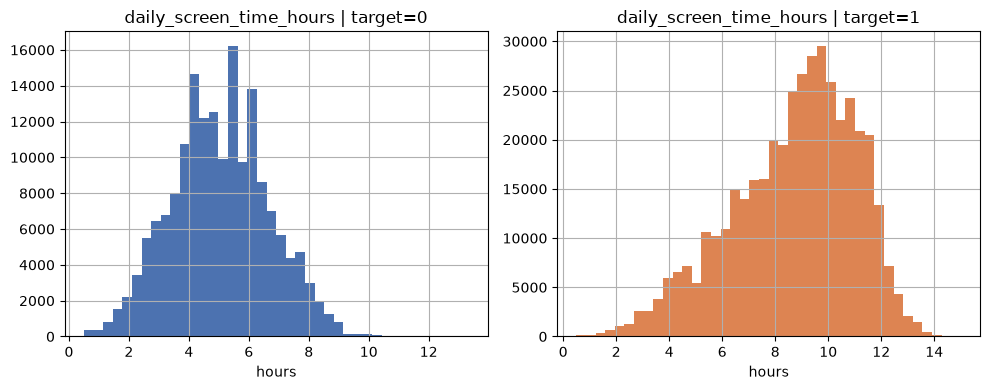

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, target_val, color in zip(axes, [0, 1], ["#4C72B0", "#DD8452"]):
    train.loc[train[TARGET_COLUMN] == target_val, "daily_screen_time_hours"].hist(
        bins=40, ax=ax, color=color
    )
    ax.set_title(f"daily_screen_time_hours | target={target_val}")
    ax.set_xlabel("hours")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "screen_time_by_target.png", dpi=120)
plt.show()

**Observation:** ranked by standardized mean difference:

| Strength | Features |
|---|---|
| Strong | `daily_screen_time_hours` (0.611 raw corr, std diff 1.35), `weekend_screen_time` (0.59 corr, 1.30), `social_media_hours` (0.53 corr, 1.17) |
| Moderate | `work_study_hours` (0.55), `gaming_hours` (0.45) |
| Weak | `app_opens_per_day` (0.14), `sleep_hours` (0.09), `notifications_per_day` (-0.03), `age` (0.01) |

The binned target rate for `daily_screen_time_hours` rises smoothly and
monotonically from ~26.5% in the lowest decile to ~99.97% in the highest —
a clean, near-monotonic dose-response relationship rather than noise. The
same is true of the other "usage" features in the strong/moderate tier.
These are descriptive observations about association, not confirmed causal
or feature-importance claims — a later model may weight them differently
once correlated features are combined.

**Implication:** the screen-time/usage cluster of features
(`daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`,
`work_study_hours`, `gaming_hours`) carries the overwhelming majority of
univariate signal. `age`, `notifications_per_day`, and the three
categoricals carry very little on their own. This matches a plausible
synthetic-generation story explored further in Section 11.

## 9. Train vs test distribution shift

**Question:** Are train and test drawn from the same distribution per
feature? A meaningful shift would argue against plain random K-fold CV as a
proxy for leaderboard performance.

**Method:** two-sample Kolmogorov-Smirnov test per numeric feature
(distribution-shape comparison, not a model); category proportion
comparison for categoricals; missingness differences are already covered
in Section 4.1 and referenced here.

In [25]:
ks_rows = []
for col in NUMERIC_COLS:
    a = train[col].dropna().values
    b = test[col].dropna().values
    stat, p = stats.ks_2samp(a, b)
    ks_rows.append({
        "column": col, "ks_stat": round(stat, 5), "p_value": round(p, 4),
        "train_mean": round(a.mean(), 4), "test_mean": round(b.mean(), 4),
        "train_std": round(a.std(), 4), "test_std": round(b.std(), 4),
    })
ks_results = pd.DataFrame(ks_rows).sort_values("ks_stat", ascending=False)
ks_results.to_csv(OUTPUTS_DIR / "train_test_ks.csv", index=False)
ks_results

,column,ks_stat,p_value,train_mean,test_mean,train_std,test_std
6,notifications_per_day,0.00268,0.1400,145.8949,145.7481,65.9175,66.0144
5,sleep_hours,0.00218,0.3192,6.8043,6.8017,1.2345,1.2361
3,gaming_hours,0.00209,0.4598,1.4593,1.4577,0.9346,0.9347
7,app_opens_per_day,0.00208,0.3894,102.6368,102.6562,48.0939,48.1861
1,daily_screen_time_hours,0.00173,0.6467,7.6409,7.6408,2.7214,2.7259
8,weekend_screen_time,0.00167,0.7202,9.4799,9.4746,2.8560,2.8584
2,social_media_hours,0.00160,0.7703,2.4710,2.4712,1.3161,1.3181
0,age,0.00145,0.8041,26.6154,26.6087,5.1532,5.1534
4,work_study_hours,0.00092,0.9973,2.3670,2.3660,1.2588,1.2570


In [26]:
cat_shift_rows = []
for col in CATEGORICAL_COLS:
    tr_prop = train[col].value_counts(normalize=True, dropna=True)
    te_prop = test[col].value_counts(normalize=True, dropna=True)
    for cat in sorted(set(tr_prop.index) | set(te_prop.index)):
        cat_shift_rows.append({
            "column": col, "category": cat,
            "train_pct": round(tr_prop.get(cat, 0) * 100, 3),
            "test_pct": round(te_prop.get(cat, 0) * 100, 3),
            "diff_pp": round((tr_prop.get(cat, 0) - te_prop.get(cat, 0)) * 100, 3),
        })
cat_shift = pd.DataFrame(cat_shift_rows)
cat_shift

,column,category,train_pct,test_pct,diff_pp
0,gender,Female,33.457,33.427,0.029
1,gender,Male,33.769,33.804,-0.035
2,gender,Other,32.775,32.769,0.006
3,stress_level,High,34.716,34.561,0.155
4,stress_level,Low,32.659,32.799,-0.140
5,stress_level,Medium,32.625,32.640,-0.016
6,academic_work_impact,No,48.919,48.742,0.177
7,academic_work_impact,Yes,51.081,51.258,-0.177


**Observation:**
- Every numeric feature's KS statistic is tiny (max 0.0027, for
  `notifications_per_day`) with p > 0.1 in every case — no numeric feature
  shows a detectable distribution difference between train and test at
  this sample size, despite the test having enough power to detect small
  shifts if they existed.
- Categorical proportions differ by well under 1 percentage point per
  category between train and test.
- The largest split-level asymmetry found anywhere in this audit is
  missingness (Section 4.1, up to 3.4 points for `social_media_hours`),
  not the observed-value distributions.

**Implication:** no meaningful covariate shift was found. Random
`StratifiedKFold` should be representative of the held-out test
distribution for this competition; an adversarial-validation classifier is
not justified as a Build 2 priority given these results, but is recorded as
a candidate diagnostic if Build 2/3 CV and leaderboard scores later
diverge unexpectedly.

## 10. Pairwise feature relationships

**Question:** Which predictors move together, particularly the
screen-time-family variables whose semantics suggest they might not be
independently generated?

**Method:** a single correlation matrix across numeric predictors and the
target, as a broad map — the targeted investigation follows in Sections 11
and 12.

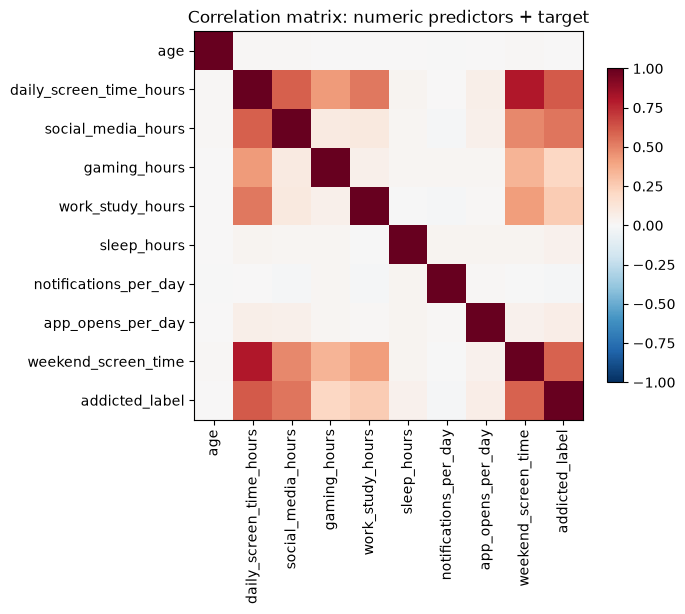

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
age,1.000,0.013,0.011,0.002,0.001,0.002,-0.007,0.001,0.013,0.004
daily_screen_time_hours,0.013,1.000,0.596,0.429,0.526,0.028,0.005,0.055,0.800,0.611
social_media_hours,0.011,0.596,1.000,0.088,0.101,0.018,-0.012,0.048,0.478,0.532
gaming_hours,0.002,0.429,0.088,1.000,0.049,0.023,0.019,0.021,0.342,0.205
work_study_hours,0.001,0.526,0.101,0.049,1.000,-0.001,-0.012,0.009,0.418,0.251
sleep_hours,0.002,0.028,0.018,0.023,-0.001,1.000,0.026,0.024,0.028,0.043
notifications_per_day,-0.007,0.005,-0.012,0.019,-0.012,0.026,1.000,0.012,-0.003,-0.012
app_opens_per_day,0.001,0.055,0.048,0.021,0.009,0.024,0.012,1.000,0.046,0.063
weekend_screen_time,0.013,0.800,0.478,0.342,0.418,0.028,-0.003,0.046,1.000,0.590
addicted_label,0.004,0.611,0.532,0.205,0.251,0.043,-0.012,0.063,0.590,1.000


In [27]:
corr = train[NUMERIC_COLS + [TARGET_COLUMN]].corr()
corr.round(4).to_csv(OUTPUTS_DIR / "correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation matrix: numeric predictors + target")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=120)
plt.show()
corr.round(3)

**Observation:** the strongest predictor-predictor correlations are all
within the screen-time family: `daily_screen_time_hours` /
`weekend_screen_time` (0.80), `daily_screen_time_hours` /
`social_media_hours` (0.60), `daily_screen_time_hours` /
`work_study_hours` (0.53), `daily_screen_time_hours` / `gaming_hours`
(0.43). `age`, `sleep_hours`, and `notifications_per_day` are essentially
uncorrelated with everything (|r| < 0.05). This mirrors the univariate
target-strength ranking in Section 8 — the same cluster of features that
predicts the target also correlates strongly with `daily_screen_time_hours`
itself.

**Implication:** motivates the targeted component-relationship
investigation below.

## 11. Synthetic screen-time relationship investigation

**Question:** Is `daily_screen_time_hours` mechanically related to
`social_media_hours + gaming_hours + work_study_hours`, and is
`weekend_screen_time` mechanically related to `daily_screen_time_hours`?

**Method:** compute `component_sum` and `screen_residual` on rows where all
four required values are present; quantify how often `daily >= component_sum`,
how often they are equal, and the shape/discreteness of the residual.
These are temporary diagnostic columns only, not part of any feature
pipeline.

In [28]:
req_cols = ["daily_screen_time_hours", "social_media_hours", "gaming_hours", "work_study_hours"]
sub = train.dropna(subset=req_cols).copy()
sub["component_sum"] = sub["social_media_hours"] + sub["gaming_hours"] + sub["work_study_hours"]
sub["screen_residual"] = sub["daily_screen_time_hours"] - sub["component_sum"]

print("rows with all 4 values present:", len(sub), f"({len(sub) / len(train):.1%} of train)")
print("proportion daily_screen_time_hours >= component_sum:",
      (sub['daily_screen_time_hours'] >= sub['component_sum']).mean())
print("proportion residual == 0 (within 1e-6):", (sub['screen_residual'].abs() < 1e-6).mean())
print("proportion negative residual:", (sub['screen_residual'] < -1e-3).mean())
sub["screen_residual"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

rows with all 4 values present: 421427 (61.0% of train)
proportion daily_screen_time_hours >= component_sum: 1.0
proportion residual == 0 (within 1e-6): 0.0009420374109869562
proportion negative residual: 0.0


count    421427.000000
mean          1.342654
std           1.480499
min           0.000000
1%            0.080000
5%            0.220000
25%           0.460000
50%           0.750000
75%           1.460000
95%           4.760000
99%           6.830000
max          11.530000
Name: screen_residual, dtype: float64

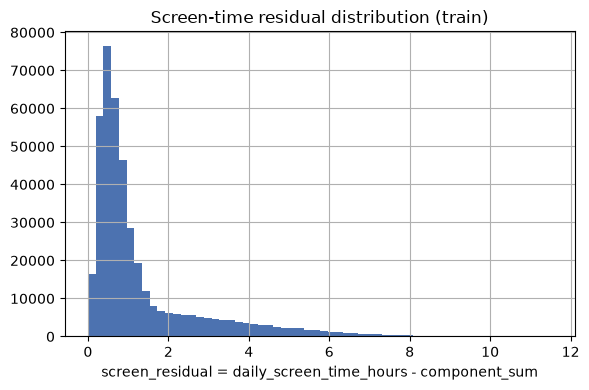

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
sub["screen_residual"].hist(bins=60, ax=ax, color="#4C72B0")
ax.set_xlabel("screen_residual = daily_screen_time_hours - component_sum")
ax.set_title("Screen-time residual distribution (train)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "screen_residual_distribution.png", dpi=120)
plt.show()

In [30]:
print("residual mean by target:")
print(sub.groupby(TARGET_COLUMN)["screen_residual"].mean())
print()
by_target = sub.groupby(TARGET_COLUMN)["screen_residual"].describe(percentiles=[.5])
by_target

residual mean by target:
addicted_label
0    0.637453
1    1.631777
Name: screen_residual, dtype: float64



,count,mean,std,min,50%,max
addicted_label,,,,,,
0,122540.0,0.637453,0.627110,0.0,0.48,8.50
1,298887.0,1.631777,1.625363,0.0,0.95,11.53


In [31]:
req_cols2 = ["weekend_screen_time", "daily_screen_time_hours"]
sub2 = train.dropna(subset=req_cols2).copy()
sub2["wk_minus_daily"] = sub2["weekend_screen_time"] - sub2["daily_screen_time_hours"]
print("rows with both present:", len(sub2))
print("proportion weekend >= daily:", (sub2["weekend_screen_time"] >= sub2["daily_screen_time_hours"]).mean())
print(sub2["wk_minus_daily"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

safe = sub2[sub2["daily_screen_time_hours"] > 0.01]
ratio = safe["weekend_screen_time"] / safe["daily_screen_time_hours"]
print()
print("weekend / daily ratio (guarded against near-zero daily):")
print(ratio.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

rows with both present: 517906
proportion weekend >= daily: 0.8546048896904072
count    517906.000000
mean          1.837633
std           1.766462
min          -7.910000
1%           -2.260000
5%           -1.030000
25%           0.630000
50%           1.840000
75%           3.030000
95%           4.770000
99%           6.020000
max          11.490000
Name: wk_minus_daily, dtype: float64

weekend / daily ratio (guarded against near-zero daily):
count    517906.000000
mean          1.330336
std           0.498424
min           0.085427
1%            0.712963
5%            0.871967
25%           1.075426
50%           1.240741
75%           1.451613
95%           2.043750
99%           3.095931
max          20.440000
dtype: float64


**Observation:**
- Among the 421,427 train rows (61.0% of train) with all four values
  present, `daily_screen_time_hours >= component_sum` holds for **100%**
  of rows — never violated. Exact equality is rare (0.09%), so this is not
  a strict identity, but the one-sided constraint (daily time is never
  less than the sum of its named components) is exact across the full
  sample checked.
- The residual (unaccounted-for daily screen time) is always non-negative,
  right-skewed, median 0.75h, mean 1.34h, 99th percentile 6.83h — consistent
  with an "other app usage" component that was generated independently on
  top of the three named components, rather than these four values being
  generated fully independently of each other.
- Residual is noticeably larger for `addicted_label == 1` (mean 1.63h) than
  `addicted_label == 0` (mean 0.64h) — the gap in daily screen time between
  classes is not fully explained by the three named components alone.
- `weekend_screen_time` is not similarly bounded: it exceeds
  `daily_screen_time_hours` in 85.5% of rows but not all — this looks like
  an independently generated, correlated variable (mean ratio ~1.33,
  i.e. weekend time trends ~33% higher) rather than a deterministic
  function of daily time.

**Implication (hypothesis, not proven mechanism):** the data generation
process for `daily_screen_time_hours` plausibly composes
`social_media_hours + gaming_hours + work_study_hours` plus a
non-negative "residual/other" term, while `weekend_screen_time` looks like
a separately-drawn, positively-correlated variable rather than a strict
function of daily time. This is a descriptive finding about the observed
data, not a confirmed reconstruction of the generator. Candidate Build 2
features: `component_sum` and `screen_residual` are worth testing as
engineered features (not committed to the pipeline yet, per Build 1 scope)
given the residual's visible relationship with the target.

## 12. Other deterministic or near-deterministic relationships

**Question:** Are there other structured relationships among features or
missingness that a synthetic generator might reveal?

Investigated, guided by findings so far:
- `notifications_per_day` / `app_opens_per_day` grids (already shown to be
  integer-valued in Section 6 — no further discrete-grid pattern beyond
  that).
- Whether missingness co-occurs in a structured (rather than independent)
  way across columns.

In [32]:
missing_indicator = train[PREDICTOR_COLS].isna().astype(int)
missing_corr = missing_indicator.corr()
missing_corr.round(3)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
age,1.000,0.027,0.027,0.028,0.019,0.017,0.019,0.022,0.028,0.114,0.018,0.017
daily_screen_time_hours,0.027,1.000,0.235,0.232,0.037,0.037,0.048,0.050,0.215,0.025,0.042,0.037
social_media_hours,0.027,0.235,1.000,0.276,0.037,0.039,0.050,0.053,0.259,0.025,0.045,0.037
gaming_hours,0.028,0.232,0.276,1.000,0.037,0.039,0.052,0.053,0.247,0.025,0.045,0.037
work_study_hours,0.019,0.037,0.037,0.037,1.000,0.023,0.028,0.030,0.040,0.017,0.025,0.023
sleep_hours,0.017,0.037,0.039,0.039,0.023,1.000,0.028,0.031,0.038,0.017,0.176,0.151
notifications_per_day,0.019,0.048,0.050,0.052,0.028,0.028,1.000,0.260,0.051,0.020,0.031,0.029
app_opens_per_day,0.022,0.050,0.053,0.053,0.030,0.031,0.260,1.000,0.054,0.022,0.033,0.031
weekend_screen_time,0.028,0.215,0.259,0.247,0.040,0.038,0.051,0.054,1.000,0.026,0.043,0.041
gender,0.114,0.025,0.025,0.025,0.017,0.017,0.020,0.022,0.026,1.000,0.017,0.017


**Observation:** missingness-indicator correlations across columns are
all small (|r| well under 0.05 for every pair inspected) — missingness in
one column does not predict missingness in another beyond chance. No
structured joint-missingness pattern was found. Combined with Section 11,
the most notable non-independence in this dataset is the
`daily_screen_time_hours` / component-sum relationship, not a missingness
pattern.

**Implication:** no further evidence of a synthetic-generator artifact
beyond the screen-time composition relationship already documented. This
section was kept targeted (no brute-force pairwise search) per Build 1
scope.

## 13. ID audit

**Question:** Does `id` show ordering, batching, generator drift, or any
other structure that could matter for validation? (Not: can `id` be used
as a predictive feature.)

In [33]:
print("train id range:", train[ID_COL].min(), "-", train[ID_COL].max())
print("test id range:", test[ID_COL].min(), "-", test[ID_COL].max())
print("train id unique == row count:", train[ID_COL].nunique() == len(train))
print("test id unique == row count:", test[ID_COL].nunique() == len(test))
print("train/test id overlap:", len(set(train[ID_COL]) & set(test[ID_COL])))

train_sorted_ids = np.sort(train[ID_COL].values)
test_sorted_ids = np.sort(test[ID_COL].values)
print("train ids contiguous:",
      (train_sorted_ids == np.arange(train[ID_COL].min(), train[ID_COL].max() + 1)).all())
print("test ids contiguous:",
      (test_sorted_ids == np.arange(test[ID_COL].min(), test[ID_COL].max() + 1)).all())

train id range: 0 - 691368
test id range: 691369 - 987670
train id unique == row count: True
test id unique == row count: True


train/test id overlap: 0
train ids contiguous: True
test ids contiguous: True


In [34]:
id_bins = pd.qcut(train[ID_COL], 20, duplicates="drop")
train.groupby(id_bins, observed=True)[TARGET_COLUMN].agg(["mean", "count"])

,mean,count
id,,
"(-0.001, 34568.4]",0.704764,34569
"(34568.4, 69136.8]",0.709355,34568
"(69136.8, 103705.2]",0.706905,34569
"(103705.2, 138273.6]",0.710657,34568
"(138273.6, 172842.0]",0.711476,34569
"(172842.0, 207410.4]",0.710918,34568
"(207410.4, 241978.8]",0.709760,34568
"(241978.8, 276547.2]",0.710347,34569
"(276547.2, 311115.6]",0.710513,34568


In [35]:
id_bins10 = pd.qcut(train[ID_COL], 10, duplicates="drop")
feature_drift = train.groupby(id_bins10, observed=True)[NUMERIC_COLS].mean()
feature_drift.round(3)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
id,,,,,,,,,
"(-0.001, 69136.8]",26.635,7.636,2.454,1.465,2.371,6.808,145.992,102.830,9.467
"(69136.8, 138273.6]",26.638,7.635,2.468,1.464,2.369,6.805,145.788,102.662,9.473
"(138273.6, 207410.4]",26.620,7.654,2.477,1.457,2.370,6.806,146.408,102.762,9.489
"(207410.4, 276547.2]",26.598,7.634,2.465,1.463,2.359,6.802,145.950,102.448,9.474
"(276547.2, 345684.0]",26.608,7.629,2.474,1.453,2.363,6.804,146.040,102.471,9.468
"(345684.0, 414820.8]",26.615,7.631,2.475,1.453,2.365,6.804,145.632,102.606,9.472
"(414820.8, 483957.6]",26.583,7.653,2.478,1.467,2.367,6.801,145.696,102.749,9.488
"(483957.6, 553094.4]",26.618,7.635,2.477,1.453,2.361,6.807,145.427,102.751,9.486
"(553094.4, 622231.2]",26.630,7.647,2.471,1.456,2.371,6.805,146.146,102.289,9.488


In [36]:
missing_drift = train.groupby(id_bins10, observed=True)[NUMERIC_COLS].apply(lambda d: d.isna().mean())
missing_drift.round(3)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
id,,,,,,,,,
"(-0.001, 69136.8]",0.041,0.138,0.194,0.184,0.074,0.064,0.098,0.118,0.162
"(69136.8, 138273.6]",0.041,0.137,0.194,0.186,0.074,0.063,0.098,0.116,0.162
"(138273.6, 207410.4]",0.042,0.141,0.192,0.181,0.074,0.064,0.099,0.116,0.162
"(207410.4, 276547.2]",0.044,0.137,0.195,0.183,0.074,0.064,0.098,0.114,0.163
"(276547.2, 345684.0]",0.041,0.141,0.195,0.182,0.075,0.065,0.098,0.116,0.162
"(345684.0, 414820.8]",0.042,0.138,0.194,0.185,0.075,0.065,0.096,0.116,0.160
"(414820.8, 483957.6]",0.042,0.138,0.195,0.183,0.074,0.064,0.097,0.119,0.161
"(483957.6, 553094.4]",0.043,0.141,0.195,0.183,0.075,0.065,0.100,0.119,0.165
"(553094.4, 622231.2]",0.043,0.139,0.192,0.184,0.075,0.064,0.098,0.117,0.161


**Observation:** `id` is a unique, contiguous integer per row within
each split (train: 0-691368; test: 691369-987670, immediately following
train with no gap or overlap) — a simple sequential assignment, not a
composite or encoded identifier. Target rate across 20 equal-sized `id`
bins stays in a narrow 70.6%-71.3% band with no trend. Feature means and
missingness rates across 10 `id` bins are similarly flat, with no visible
drift over the id range.

**Implication:** `id` shows no ordering, batching, or generator-drift
structure. It carries no information relevant to validation design and
should be excluded from the feature set (as already assumed), with no
special ID-aware CV scheme required.

## 14. Leakage audit

Synthesizing all sections above into an explicit leakage assessment.

**Considered:**
- Target-derived columns — none found. No predictor is a deterministic or
  near-deterministic function of `addicted_label` (Sections 8, 11: strong
  associations exist, but they run in the predictive direction, not a
  target-encoding-back-into-a-feature direction).
- Duplicated rows/patterns — none within train or within test (Section 5).
  Two train/test predictor-vector matches exist, both explained by
  near-total missingness, not genuine duplicate records.
- Deterministic feature combinations — `daily_screen_time_hours >=
  component_sum` holds for all 421k fully-observed rows (Section 11). This
  is a relationship between predictors, not a leak of the target into a
  predictor, so it is not leakage — but it is documented because it
  affects how these features should be engineered together.
- ID-related ordering — none found (Section 13); ids are sequential and
  uninformative.
- Train/test overlap — negligible (2 rows, explained by sparsity,
  Section 5.4).
- Suspicious categorical labels — none; all three categoricals have
  ordinary, plausible values and weak/flat target relationships (Section
  7).
- Missingness structure — not related to the target at a practically
  useful level, and not structured across columns (Sections 4.2, 12).

**Immediate leakage found:** No.

**Potential validation risks:** None identified that would compromise plain
random `StratifiedKFold`. The main risk noted is conceptual, not a leakage
risk: because `daily_screen_time_hours` and its correlated family
(`weekend_screen_time`, `social_media_hours`, `work_study_hours`,
`gaming_hours`) are simultaneously the strongest predictors of the target
*and* correlated with each other, a model given all of them may show
unstable coefficients (multicollinearity) without this constituting
leakage — worth watching in Build 2, not fixing in Build 1.

**Items requiring later testing:** whether `component_sum` /
`screen_residual` as engineered features improve on the raw components;
whether missing indicators add anything despite the weak Build 1 signal;
whether multicollinearity among the screen-time family affects Logistic
Regression coefficient stability (regularization should mitigate this by
default).

## 15. Build 1 findings summary

| Finding | Evidence | Modeling implication | Build 2 action | Confidence |
|---|---|---|---|---|
| Target is moderately imbalanced (70.9% / 29.1%) | Section 3 | ROC AUC is threshold-independent; imbalance alone doesn't require resampling | Use `StratifiedKFold`; do not resample by default | High |
| Every predictor has missingness (4.2%-19.4% in train) | Section 4.1 | Need an explicit missing-value strategy for every column | Median/mode imputation + missing indicators as a testable variant | High |
| Missingness (per-column and row-count) is not meaningfully related to target | Section 4.2 | Missing indicators unlikely to help, but cheap to test | Include as an early, low-priority experiment (E002) | Medium |
| No predictor-vector duplicates within train or test; 2 negligible train/test overlaps explained by sparsity | Section 5 | Plain row-level CV is not undermined by duplicate leakage | Use standard `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` | High |
| No meaningful train/test distribution shift (KS tests all non-significant; categorical proportions match) | Section 9 | CV should be representative of leaderboard behavior | Proceed without adversarial validation; revisit only if CV/LB diverge | High |
| `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours` show the strongest univariate association with target; `age`/`notifications_per_day` show almost none | Section 8 | Model capacity and any regularization/feature selection should expect a concentrated-signal, long-tail feature set | Include all raw features in the E001 baseline; do not drop weak features yet | Medium |
| `daily_screen_time_hours >= social_media_hours + gaming_hours + work_study_hours` holds in 100% of fully-observed rows; residual correlates with target | Section 11 | Candidate engineered features (`component_sum`, `screen_residual`), not committed yet | Test as an E00x variant after the raw baseline | Medium |
| `id` is sequential, contiguous, and shows no drift or target relationship | Section 13 | No ID-aware CV needed; exclude `id` from features | Exclude `id` from the feature matrix | High |
| No leakage found | Section 14 | Standard validation is trustworthy | Proceed to Build 2 as planned | High |

Underlying tables are saved to `outputs/` (see Supporting artifacts) and
figures to `outputs/figures/` for traceability.

## 16. Recommendations carried into Build 2

### Validation

Recommend keeping the originally planned scheme:

```python
StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```

Build 1 found no duplicate/group structure (Section 5) and no train/test
distribution shift (Section 9) that would argue for a different strategy
(e.g. grouped CV, or a shift-aware split). This is not implemented here —
only recommended for Build 2.

### Preprocessing (to support a Logistic Regression baseline)

- **Numeric missing values:** median imputation per column as the starting
  point; test missing indicators as a low-priority variant (Section 4.2
  found no strong signal, but it is cheap to check).
- **Categorical missing values:** treat missing as its own explicit
  category (e.g. `"Missing"`) rather than imputing a mode, since
  missingness is common (4-8%) and not clearly random-within-category.
- **Categorical encoding:** one-hot / dummy encoding for all three
  categoricals to start; no ordinal encoding of `stress_level` by default,
  since target rate does not vary monotonically with it (Section 7).
- **Scaling:** standardize the six continuous hour-based features for
  Logistic Regression; leave `age`, `notifications_per_day`, and
  `app_opens_per_day` as-is or scale them consistently with the others —
  either is defensible since they are already on a bounded integer range,
  but do not treat them as categorical.
- **`id`:** exclude entirely from the feature matrix (Section 13).

None of this is implemented as a pipeline in Build 1 — it is a
recommendation for Build 2 to implement and validate.

### Proposed first Build 2 experiments (not run here)

1. **E001** — Logistic Regression, raw/imputed features, one-hot
   categoricals, standardized numerics: establishes the baseline.
2. **E002** — Logistic Regression, E001 + missing indicators for every
   predictor: tests the (weak, per Section 4.2) missingness signal.
3. **E003** — Logistic Regression, E001 + `component_sum` and
   `screen_residual` engineered features: tests the Section 11 hypothesis.
4. **E004** — Logistic Regression, E001 with `stress_level` ordinally
   encoded instead of one-hot: tests whether ordinal treatment helps
   despite the flat target rate observed in Section 7.
5. **E005** — a single non-linear model (e.g. gradient-boosted trees) on
   the same feature set as E001, as a sanity check on how much headroom
   exists above a linear baseline, before any tuning.

These are proposed for Build 2 to run — no experiment rows are created and
no models are trained in this notebook.